# EDA for Recipe Dataset

This notebook performs exploratory data analysis on the `tasteofhome_delish.csv` dataset, containing recipes from tasteofhome.com and delish.com.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw/tasteofhome_delish.csv', header=None, 
                 names=['id', 'title', 'ingredients', 'instructions', 'url', 'source', 'ner'])

# Parse JSON strings to lists
df['ingredients'] = df['ingredients'].apply(ast.literal_eval)
df['instructions'] = df['instructions'].apply(ast.literal_eval)
df['ner'] = df['ner'].apply(ast.literal_eval)

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (55474, 7)
        id                          title  \
0  1489221       Pear Sundae French Toast   
1  1489222           Turkey Dumpling Soup   
2  1489223       Hoosier Pork Chop Supper   
3  1489224  Eggnog Sweet Potato Casserole   
4  1489225           Amish Apple Scrapple   

                                         ingredients  \
0  [1/4 cup plus 3 tablespoons packed brown sugar...   
1  [1 meaty leftover turkey carcass (from an 11-p...   
2  [1 medium onion, sliced, 3 tablespoons vegetab...   
3  [6 cups mashed sweet potatoes (about 3 pounds)...   
4  [3/4 pound bulk pork sausage, 1/2 cup finely c...   

                                        instructions  \
0  [In a skillet, combine 1/4 cup brown sugar, 2 ...   
1  [In a stock pot, combine the first nine ingred...   
2  [In a large skillet, saute onion in oil until ...   
3  [In a large bowl, combine the potatoes, eggnog...   
4  [In a large skillet, cook sausage and onion ov...   

                             

In [4]:
# Basic information
print("Basic Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate titles:", df['title'].duplicated().sum())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55474 entries, 0 to 55473
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            55474 non-null  int64 
 1   title         55474 non-null  object
 2   ingredients   55474 non-null  object
 3   instructions  55474 non-null  object
 4   url           55474 non-null  object
 5   source        55474 non-null  object
 6   ner           55474 non-null  object
dtypes: int64(1), object(6)
memory usage: 3.0+ MB
None

Missing values:
id              0
title           0
ingredients     0
instructions    0
url             0
source          0
ner             0
dtype: int64

Duplicate titles: 360


In [7]:
# Extract website from URL
from urllib.parse import urlparse

df['website'] = df['url'].apply(lambda x: urlparse('https://' + x).netloc)

print("Website distribution:")
print(df['website'].value_counts())

Website distribution:
website
www.tasteofhome.com    51594
www.delish.com          3880
Name: count, dtype: int64


In [6]:
# Add columns for counts
df['num_ingredients'] = df['ingredients'].apply(len)
df['num_instructions'] = df['instructions'].apply(len)
df['title_length'] = df['title'].apply(len)

print("Summary statistics:")
print(df[['num_ingredients', 'num_instructions', 'title_length']].describe())

Summary statistics:
       num_ingredients  num_instructions  title_length
count     55474.000000      55474.000000  55474.000000
mean          9.926686          3.128817     23.486048
std           3.692503          2.347651      7.160847
min           1.000000          1.000000      3.000000
25%           7.000000          2.000000     19.000000
50%          10.000000          3.000000     23.000000
75%          12.000000          4.000000     27.000000
max          36.000000         34.000000     83.000000


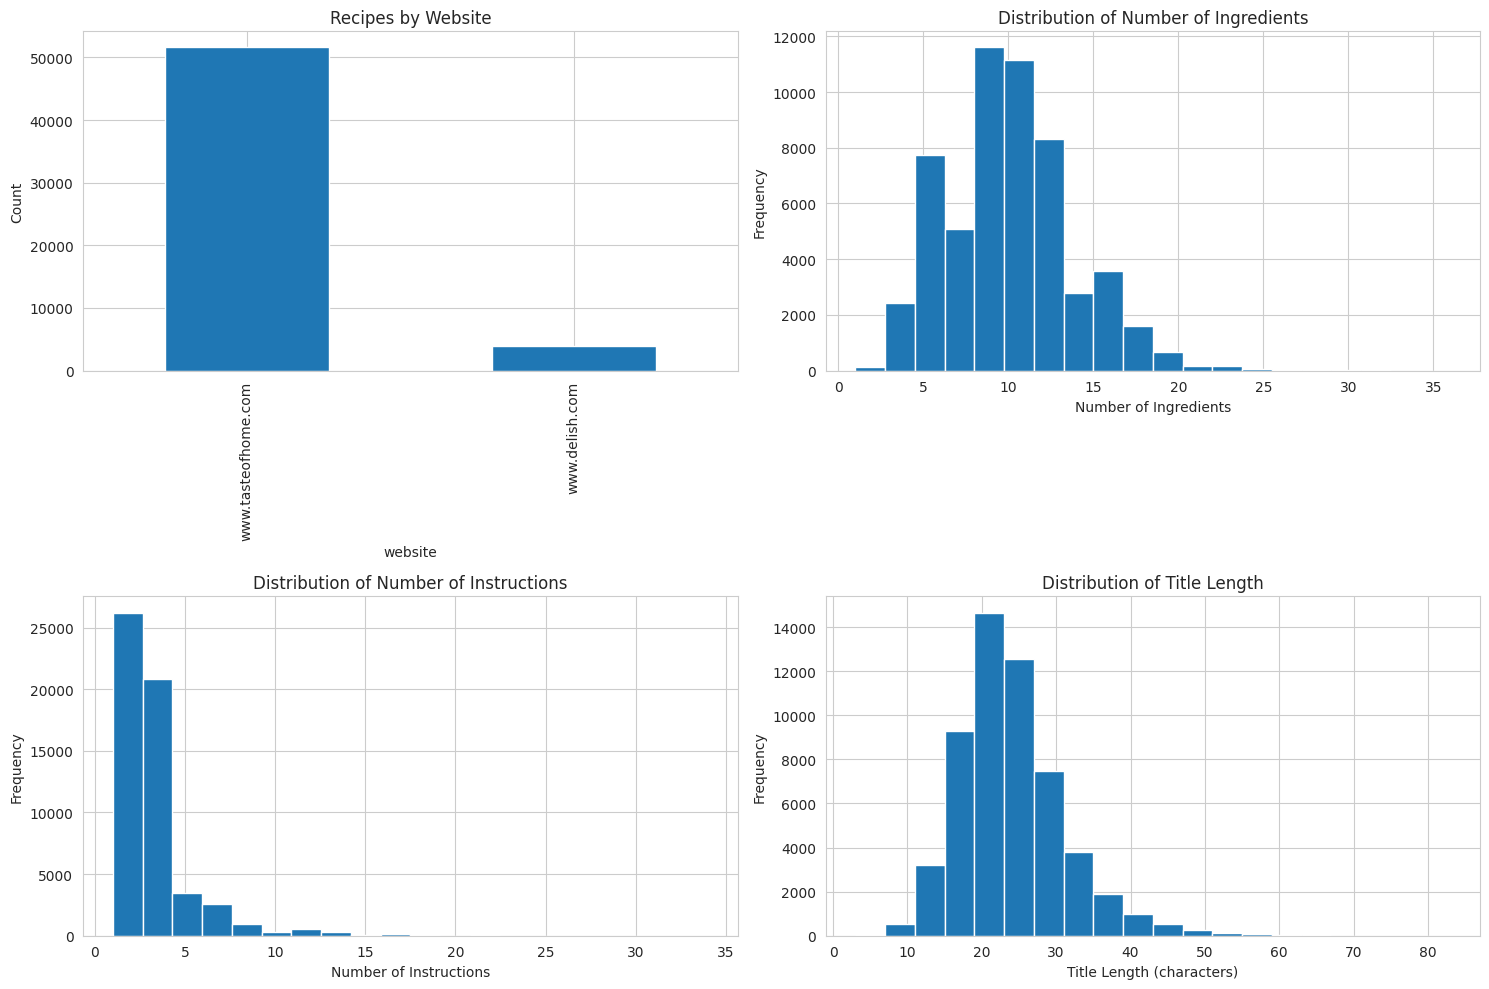

In [8]:
# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Website distribution
df['website'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Recipes by Website')
axes[0,0].set_ylabel('Count')

# Number of ingredients
df['num_ingredients'].plot(kind='hist', bins=20, ax=axes[0,1])
axes[0,1].set_title('Distribution of Number of Ingredients')
axes[0,1].set_xlabel('Number of Ingredients')

# Number of instructions
df['num_instructions'].plot(kind='hist', bins=20, ax=axes[1,0])
axes[1,0].set_title('Distribution of Number of Instructions')
axes[1,0].set_xlabel('Number of Instructions')

# Title length
df['title_length'].plot(kind='hist', bins=20, ax=axes[1,1])
axes[1,1].set_title('Distribution of Title Length')
axes[1,1].set_xlabel('Title Length (characters)')

plt.tight_layout()
plt.show()

Top 20 most common ingredients:
salt: 29521
sugar: 22117
butter: 20398
pepper: 15421
garlic: 12167
onion: 11846
milk: 10218
flour: 10090
water: 9908
eggs: 8976
vanilla: 8328
olive oil: 7443
brown sugar: 6786
lemon juice: 5598
canola oil: 5297
egg: 5142
ground cinnamon: 5129
tomatoes: 4860
baking powder: 4404
cream cheese: 4176


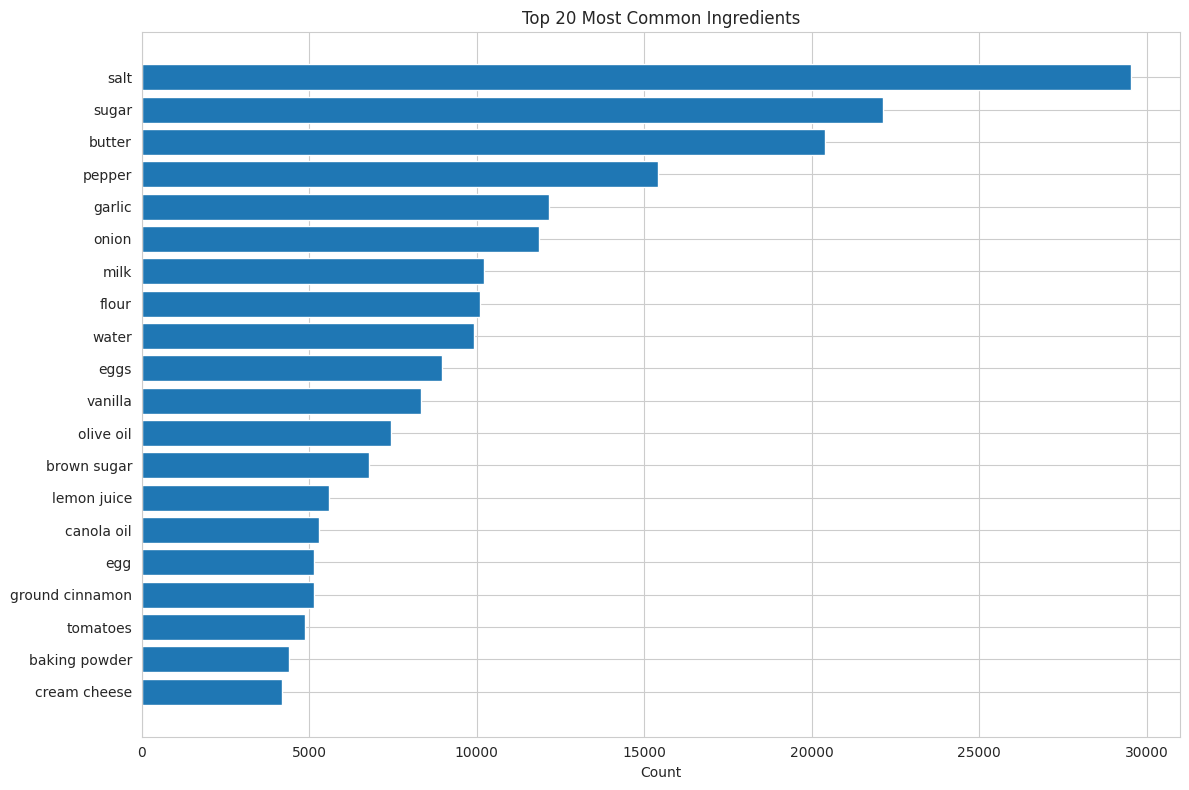

In [9]:
# Most common ingredients
all_ingredients = [ing.lower() for sublist in df['ner'] for ing in sublist]
ingredient_counts = Counter(all_ingredients)
common_ingredients = ingredient_counts.most_common(20)

print("Top 20 most common ingredients:")
for ing, count in common_ingredients:
    print(f"{ing}: {count}")

# Plot top ingredients
ingredients, counts = zip(*common_ingredients)
plt.figure(figsize=(12, 8))
plt.barh(ingredients[::-1], counts[::-1])
plt.title('Top 20 Most Common Ingredients')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

Average stats by website:
                     num_ingredients  num_instructions  title_length
website                                                             
www.delish.com              8.410567          8.509021     27.043814
www.tasteofhome.com        10.040702          2.724212     23.218494


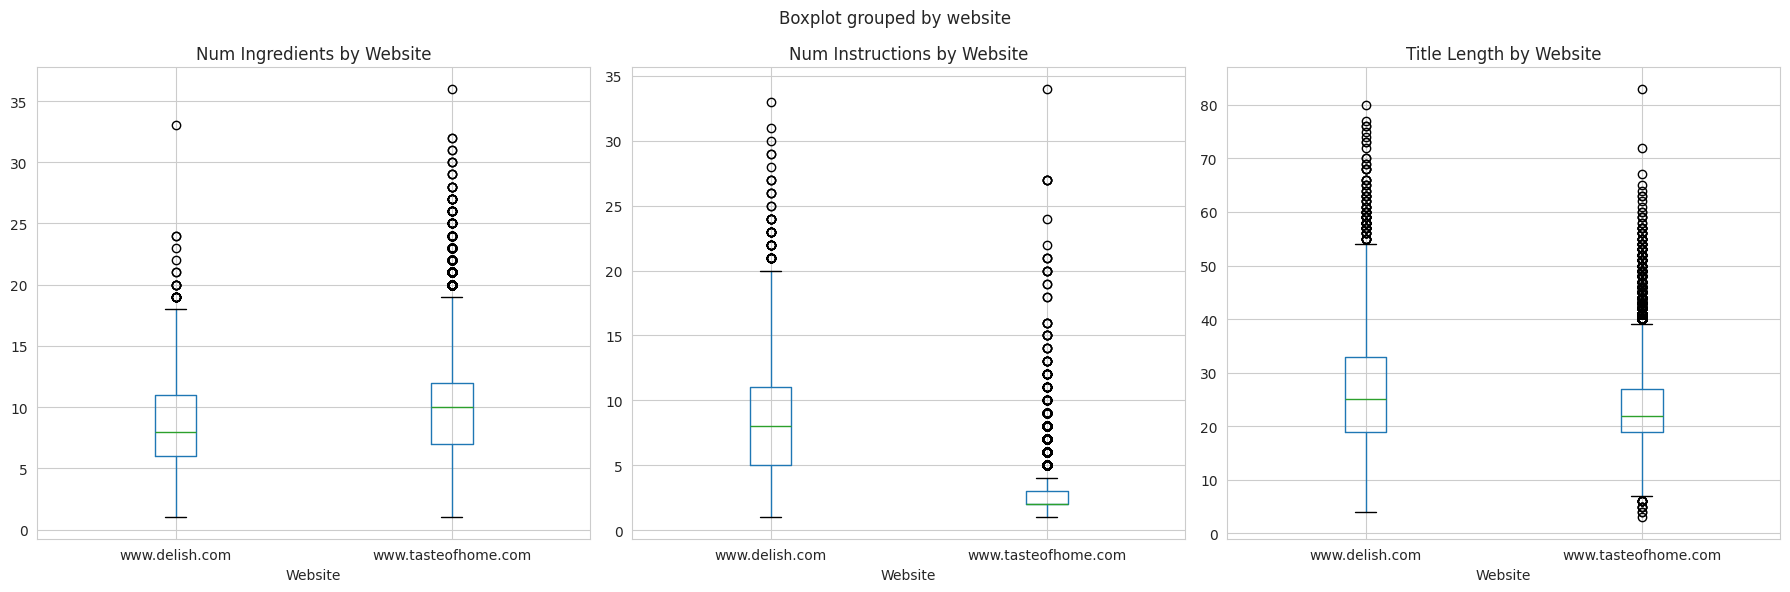

In [10]:
# Compare websites
website_stats = df.groupby('website')[['num_ingredients', 'num_instructions', 'title_length']].mean()
print("Average stats by website:")
print(website_stats)

# Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(['num_ingredients', 'num_instructions', 'title_length']):
    df.boxplot(column=col, by='website', ax=axes[i])
    axes[i].set_title(f'{col.replace("_", " ").title()} by Website')
    axes[i].set_xlabel('Website')

plt.tight_layout()
plt.show()